Nome:  Hercules André

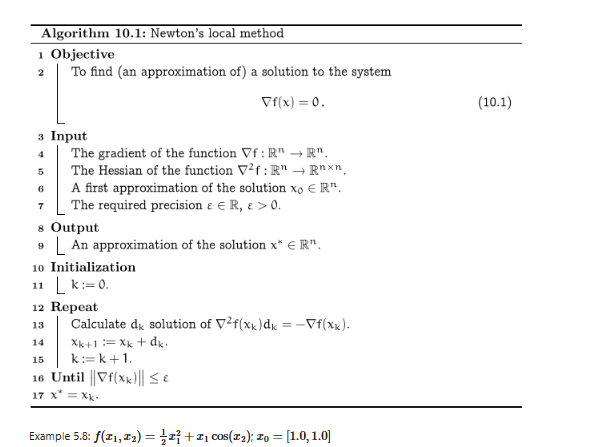

In [1]:
#Biblioteca

using LinearAlgebra

#Função

function f(x)
    return 0.5 * x[1]^2 + x[1] * cos(x[2])
end

f (generic function with 1 method)

In [2]:
# Gradiente 

function grad_f(x)

    g1 = x[1] + cos(x[2])
    g2 = -x[1] * sin(x[2])

    return [g1;g2]
end

grad_f (generic function with 1 method)

In [3]:
#Hessiana

function hess_f(x)

    h11 = 1
    h12 = -sin(x[2])

    h21 = -sin(x[2])
    h22 = -x[1] * cos(x[2])

    return [h11 h12; h21 h22]

end

hess_f (generic function with 1 method)

In [4]:
#Método de Newton Local

function newton_local(grad, hess, x0, epsilon)
    # Inicialização
    xk = x0
    k = 0
    
    println("Iteração $k: x = $xk, ||∇f|| = $(norm(grad(xk)))")
    
    # Repetir
    while norm(grad(xk)) > epsilon
        # Calcular dk (solução de ∇²f(xk)dk = -∇f(xk))
      
        dk = hess(xk) \ -grad(xk)
        
        # xk+1 := xk + dk
        xk = xk + dk
        
        # k := k + 1
        k += 1
        
        println("Iteração $k: x = $xk, ||∇f|| = $(norm(grad(xk)))")
        
        # Critério de segurança para evitar loops infinitos
        if k > 100
            println("Aviso: Máximo de iterações atingido.")
            break
        end
    end
    
    # x* = xk
    return xk
end

newton_local (generic function with 1 method)

In [7]:
# Parâmetros iniciais
x0 = [1.0, 1.0]
epsilon = 1e-6

# Chamada do método
solucao = newton_local(grad_f, hess_f, x0, epsilon)

println("\nSolução aproximada encontrada: ", solucao)

Iteração 0: x = [1.0, 1.0], ||∇f|| = 1.7551651237807455
Iteração 1: x = [-0.233845128578686, 1.3641922096213648], ||∇f|| = 0.23066538157380367
Iteração 2: x = [0.010814375288982048, 1.5848364114223852], ||∇f|| = 0.011284054489866838
Iteração 3: x = [-2.1323766610271966e-6, 1.570793271589529], ||∇f|| = 2.323498019410394e-6
Iteração 4: x = [1.990485074400243e-17, 1.5707963267948966], ||∇f|| = 8.354308348422095e-17

Solução aproximada encontrada: [1.990485074400243e-17, 1.5707963267948966]


-------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------

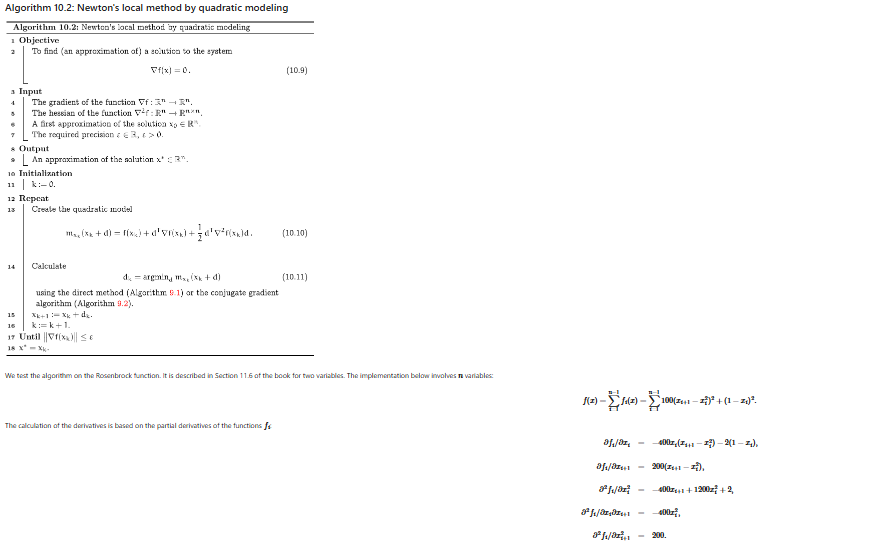

In [8]:
#Biblioteca
using LinearAlgebra

# Função de Rosenbrock para n variáveis
function f(x)
    n = length(x)
    return sum(100*(x[i+1] - x[i]^2)^2 + (1 - x[i])^2 for i in 1:n-1)
end

# Gradiente ∇f(x)
function grad_f(x)
    n = length(x)
    g = zeros(n)
    for i in 1:n-1
        g[i]   += -400*x[i]*(x[i+1] - x[i]^2) - 2*(1 - x[i])
        g[i+1] += 200*(x[i+1] - x[i]^2)
    end
    return g
end

# Hessiana ∇²f(x)
function hessian_f(x)
    n = length(x)
    H = zeros(n, n)
    for i in 1:n-1
        H[i, i]     += 1200*x[i]^2 - 400*x[i+1] + 2
        H[i, i+1]   += -400*x[i]
        H[i+1, i]   += -400*x[i]
        H[i+1, i+1] += 200
    end
    return H
end

hessian_f (generic function with 1 method)

In [9]:
#Newton Local

function newton_local_method(x0, epsilon; max_iter=100)
    xk = copy(x0)
    k = 0
    
    println("Iteração | ||∇f(xk)||")
    println("-----------------------")
    
    # Loop de Repetição (Repeat)
    while true
        gk = grad_f(xk)
        norm_gk = norm(gk)
        
        println("   $k     |  $(round(norm_gk, digits=6))")
        
        # Critério de Parada: ||∇f(xk)|| ≤ ε
        if norm_gk <= epsilon || k >= max_iter
            break
        end
        
        # Calcular a Hessiana para o modelo quadrático
        Hk = hessian_f(xk)
        
        # Calcular dk = argmin mk(xk + d) 
        # Resolvendo o sistema linear: Hk * dk = -gk
        dk = Hk \ -gk
        
        # Atualização: x_{k+1} = xk + dk
        xk = xk + dk
        k += 1
    end
    
    return xk, k
end

newton_local_method (generic function with 1 method)

In [10]:
# Para teste :  epsilon = 1e-6

#Ponto inicial 
x0 = [0.0, 0.0]

#Precisão
epsilon = 1e-6

#Execução
x_opt, total_iter = newton_local_method(x0, epsilon)

Iteração | ||∇f(xk)||
-----------------------
   0     |  2.0
   1     |  447.213595
   2     |  0.0


([1.0, 1.0], 2)

In [11]:
#Resultado 

println("-----------------------")
println("Solução aproximada x*: ", x_opt)
println("Número de iterações: ", total_iter)
println("Valor final da função: ", f(x_opt))

-----------------------
Solução aproximada x*: [1.0, 1.0]
Número de iterações: 2
Valor final da função: 0.0


---------------------------------------------------------------------------------------------------------

In [1]:
#Biblioteca
using LinearAlgebra

# Função objetivo
f(x) = 0.5 * x[1]^2 + x[1] * cos(x[2])

# Gradiente 
function grad_f(x)
    return [x[1] + cos(x[2]), -x[1] * sin(x[2])]
end

# Hessiana 
function hess_f(x)
    h11 = 1.0
    h12 = -sin(x[2])
    h21 = -sin(x[2])
    h22 = -x[1] * cos(x[2])
    return [h11 h12; h21 h22]
end

hess_f (generic function with 1 method)

In [4]:
#Implementação do Algoritmo

function newton_globalizado(x0, eps, max_iter=100)
    xk = x0
    println("Iniciando busca a partir de: $xk")
    
    for k in 0:max_iter
        gk = grad_f(xk)
        Hk = hess_f(xk)
        
        # Critério de Parada: ||∇f(xk)|| ≤ ε
        norm_g = norm(gk)
        if norm_g <= eps
           println("Convergência atingida na iteração $(k)!")
            return xk
        end
        
        # Tratamento do erro mencionado: Garantir que a Hessiana seja inversível
        # Se det(Hk) for muito pequeno ou não definida positiva, aplicamos um ajuste
        dk = try
            Hk \ -gk
        catch
            println("Hessiana instável na iteração $k. Aplicando regularização...")
            (Hk + 1e-5*I) \ -gk
        end
        
        # Atualização do passo
        xk = xk + dk
        
        println("Iteração $k: x = $xk, ||∇f|| = $norm_g")
    end
    return xk
end

newton_globalizado (generic function with 2 methods)

In [5]:
# Ponto inicial e precisão
x_start = [1.0, 1.0]
epsilon = 1e-6

# Execução
resultado = newton_globalizado(x_start, epsilon)

println("\nResultado final: ", resultado)

Iniciando busca a partir de: [1.0, 1.0]
Iteração 0: x = [-0.233845128578686, 1.3641922096213648], ||∇f|| = 1.7551651237807455
Iteração 1: x = [0.010814375288982048, 1.5848364114223852], ||∇f|| = 0.23066538157380367
Iteração 2: x = [-2.1323766610271966e-6, 1.570793271589529], ||∇f|| = 0.011284054489866838
Iteração 3: x = [1.990485074400243e-17, 1.5707963267948966], ||∇f|| = 2.323498019410394e-6
Convergência atingida na iteração 4!

Resultado final: [1.990485074400243e-17, 1.5707963267948966]


--------------------------------------------------------------------------------------------------------

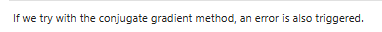

In [6]:
using LinearAlgebra


f(x) = 0.5 * x[1]^2 + x[1] * cos(x[2]) #Função
grad_f(x) = [x[1] + cos(x[2]), -x[1] * sin(x[2])] #Gradiente
hess_f(x) = [1.0 -sin(x[2]); -sin(x[2]) -x[1]*cos(x[2])] #Hessiana



hess_f (generic function with 1 method)

In [7]:
# Algoritmo de Gradiente Conjugado Linear para resolver Ax = b
function gradiente_conjugado_linear(A, b; tol=1e-8)
    x = zeros(length(b))
    r = b - A * x
    p = r
    rsold = dot(r, r)
    
    for i in 1:length(b)
        Ap = A * p
        alpha = rsold / dot(p, Ap) # Aqui o erro ocorre se dot(p, Ap) <= 0
        
        if dot(p, Ap) <= 0
            error("Erro: A matriz não é definida positiva (p'Ap = $(dot(p, Ap))). O CG falhou.")
        end
        
        x = x + alpha * p
        r = r - alpha * Ap
        rsnew = dot(r, r)
        if sqrt(rsnew) < tol
            break
        end
        p = r + (rsnew / rsold) * p
        rsold = rsnew
    end
    return x
end

gradiente_conjugado_linear (generic function with 1 method)

In [8]:
#Gradiente Conjugado

function newton_cg(x0, eps)
    xk = x0
    println("Ponto Inicial: $xk")
    
    gk = grad_f(xk)
    Hk = hess_f(xk)
    
    println("Hessiana em x0: \n", Hk)
    println("Autovalores da Hessiana: ", eigen(Hk).values)
    
    try
        # Tentando resolver ∇²f(xk) dk = -∇f(xk) usando CG
        dk = gradiente_conjugado_linear(Hk, -gk)
        xk = xk + dk
        println("Novo ponto: $xk")
    catch e
        println("\n[STATUS] Conforme a imagem image_9f276b.png:")
        println(e.msg)
    end
end

# Execução
x0 = [1.0, 1.0]
newton_cg(x0, 1e-6)

Ponto Inicial: [1.0, 1.0]
Hessiana em x0: 
[1.0 -0.8414709848078965; -0.8414709848078965 -0.5403023058681398]
Autovalores da Hessiana: [-0.910855416378039, 1.3705531105098994]

[STATUS] Conforme a imagem image_9f276b.png:
Erro: A matriz não é definida positiva (p'Ap = -0.057949929287297225). O CG falhou.
